In [1]:
# 6-22-2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

In [2]:
rf_t = pd.read_csv("transfer_matrix_spearman_rf.csv")
xgb_t = pd.read_csv("transfer_matrix_spearman_xgb.csv")
nn_t = pd.read_csv("transfer_matrix_spearman_nn.csv")

In [3]:
rf_t.head()

,Unnamed: 0,0,1,2,4,5,6,7,8,11,...,32,33,36,37,38,39,45,46,47,49
0,0,0.392855,0.290849,0.128428,0.054446,0.213909,0.087892,0.152805,0.182725,0.175080,...,0.226954,0.241617,0.148503,0.272692,0.111680,-0.013762,0.117464,0.163298,0.028433,0.033285
1,1,0.140050,0.395756,0.049440,0.007159,0.184123,0.066385,0.063603,0.134836,0.104308,...,0.173615,0.043663,0.030789,0.193711,0.067833,0.066370,0.113758,0.200665,0.012426,-0.033455
2,2,0.197478,0.216357,0.368561,0.022614,0.210764,0.146139,0.166881,0.233484,0.156126,...,0.199903,0.219109,0.122159,0.253776,0.129618,0.051029,-0.008378,0.260843,0.025048,0.063180
3,4,0.233598,0.223307,0.128421,0.410325,0.217037,0.183353,0.118123,0.202430,0.169613,...,0.181329,0.243651,0.147356,0.284894,0.213711,-0.003993,0.053143,0.305150,0.138506,0.028815
4,5,0.191233,0.207653,0.094644,0.086692,0.464396,0.146544,0.154414,0.201536,0.261764,...,0.199348,0.234613,0.115991,0.294817,0.169369,-0.025139,0.114958,0.298911,0.068162,0.056954


In [4]:
rf_t.set_index("Unnamed: 0", inplace=True)
rf_t.index.name = None

In [5]:
rf_t.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392855,0.290849,0.128428,0.054446,0.213909,0.087892,0.152805,0.182725,0.175080,0.027583,...,0.226954,0.241617,0.148503,0.272692,0.111680,-0.013762,0.117464,0.163298,0.028433,0.033285
1,0.140050,0.395756,0.049440,0.007159,0.184123,0.066385,0.063603,0.134836,0.104308,0.030660,...,0.173615,0.043663,0.030789,0.193711,0.067833,0.066370,0.113758,0.200665,0.012426,-0.033455
2,0.197478,0.216357,0.368561,0.022614,0.210764,0.146139,0.166881,0.233484,0.156126,0.060366,...,0.199903,0.219109,0.122159,0.253776,0.129618,0.051029,-0.008378,0.260843,0.025048,0.063180
4,0.233598,0.223307,0.128421,0.410325,0.217037,0.183353,0.118123,0.202430,0.169613,0.036186,...,0.181329,0.243651,0.147356,0.284894,0.213711,-0.003993,0.053143,0.305150,0.138506,0.028815
5,0.191233,0.207653,0.094644,0.086692,0.464396,0.146544,0.154414,0.201536,0.261764,0.105262,...,0.199348,0.234613,0.115991,0.294817,0.169369,-0.025139,0.114958,0.298911,0.068162,0.056954


In [6]:
xgb_t.head()

,Unnamed: 0,0,1,2,4,5,6,7,8,11,...,32,33,36,37,38,39,45,46,47,49
0,0,0.340479,0.268365,0.023255,0.073371,0.203848,0.084109,0.144361,0.091938,0.172346,...,0.189594,0.219888,0.123013,0.275676,0.093795,0.008626,0.097742,0.101453,0.053211,0.039357
1,1,0.130374,0.363223,0.004915,0.026436,0.196109,0.028512,0.146295,0.032563,0.148122,...,0.211636,0.060401,0.025993,0.235225,0.129532,0.043776,0.108788,0.102869,0.027382,-0.006507
2,2,0.158666,0.179357,0.299131,0.083269,0.147714,0.072678,0.092537,0.145160,0.159003,...,0.176229,0.165970,0.096143,0.211042,0.032863,0.076805,0.042326,0.054624,0.086426,-0.032850
3,4,0.176460,0.233192,0.070815,0.339380,0.104151,0.182697,0.081252,0.172169,0.068067,...,0.152971,0.193996,0.125479,0.242181,0.132990,-0.004366,0.023557,0.296029,0.078820,0.065330
4,5,0.057727,0.097891,0.026106,0.002197,0.408792,0.040854,0.080465,0.202452,0.166424,...,0.127916,0.134689,0.061794,0.244491,0.083776,0.016166,0.113704,0.108696,0.016897,0.035414


In [7]:
xgb_t.set_index("Unnamed: 0", inplace=True)
xgb_t.index.name = None
xgb_t.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.340479,0.268365,0.023255,0.073371,0.203848,0.084109,0.144361,0.091938,0.172346,0.041892,...,0.189594,0.219888,0.123013,0.275676,0.093795,0.008626,0.097742,0.101453,0.053211,0.039357
1,0.130374,0.363223,0.004915,0.026436,0.196109,0.028512,0.146295,0.032563,0.148122,0.053528,...,0.211636,0.060401,0.025993,0.235225,0.129532,0.043776,0.108788,0.102869,0.027382,-0.006507
2,0.158666,0.179357,0.299131,0.083269,0.147714,0.072678,0.092537,0.145160,0.159003,0.051983,...,0.176229,0.165970,0.096143,0.211042,0.032863,0.076805,0.042326,0.054624,0.086426,-0.032850
4,0.176460,0.233192,0.070815,0.339380,0.104151,0.182697,0.081252,0.172169,0.068067,0.029840,...,0.152971,0.193996,0.125479,0.242181,0.132990,-0.004366,0.023557,0.296029,0.078820,0.065330
5,0.057727,0.097891,0.026106,0.002197,0.408792,0.040854,0.080465,0.202452,0.166424,0.075737,...,0.127916,0.134689,0.061794,0.244491,0.083776,0.016166,0.113704,0.108696,0.016897,0.035414


In [8]:
nn_t.head()

,Unnamed: 0,0,1,2,4,5,6,7,8,11,...,32,33,36,37,38,39,45,46,47,49
0,0,0.327229,0.257438,0.120159,0.123036,0.183881,0.053011,0.078471,0.082923,0.186895,...,0.161021,0.128568,0.147927,0.295138,0.173672,0.024648,0.027077,0.076266,0.038750,0.031318
1,1,0.142303,0.304523,0.061035,0.099681,0.169610,0.057565,0.107336,0.139577,0.152684,...,0.093961,0.009327,0.103113,0.239656,0.134745,-0.011778,-0.049085,0.106144,0.077949,0.027953
2,2,-0.031146,0.040359,0.265827,0.111264,-0.012327,0.085594,-0.018600,-0.040654,0.023416,...,0.019639,0.021920,0.033017,0.035224,-0.028475,0.010882,-0.067476,0.048520,0.037771,-0.061132
3,4,0.215056,0.212925,0.126851,0.308778,0.193080,0.186108,0.181114,0.195278,0.187929,...,0.177927,0.231047,0.169772,0.285454,0.217200,0.058896,0.024155,0.279515,0.138723,0.050509
4,5,0.077664,0.047553,0.079990,0.089583,0.367516,0.089286,0.095409,0.127508,0.180534,...,0.084525,-0.086725,0.116447,0.248129,0.109446,-0.024253,0.134504,0.043670,0.120702,0.033253


In [9]:
nn_t.set_index("Unnamed: 0", inplace=True)
nn_t.index.name = None
nn_t.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.327229,0.257438,0.120159,0.123036,0.183881,0.053011,0.078471,0.082923,0.186895,0.051496,...,0.161021,0.128568,0.147927,0.295138,0.173672,0.024648,0.027077,0.076266,0.038750,0.031318
1,0.142303,0.304523,0.061035,0.099681,0.169610,0.057565,0.107336,0.139577,0.152684,0.072075,...,0.093961,0.009327,0.103113,0.239656,0.134745,-0.011778,-0.049085,0.106144,0.077949,0.027953
2,-0.031146,0.040359,0.265827,0.111264,-0.012327,0.085594,-0.018600,-0.040654,0.023416,0.000317,...,0.019639,0.021920,0.033017,0.035224,-0.028475,0.010882,-0.067476,0.048520,0.037771,-0.061132
4,0.215056,0.212925,0.126851,0.308778,0.193080,0.186108,0.181114,0.195278,0.187929,0.120606,...,0.177927,0.231047,0.169772,0.285454,0.217200,0.058896,0.024155,0.279515,0.138723,0.050509
5,0.077664,0.047553,0.079990,0.089583,0.367516,0.089286,0.095409,0.127508,0.180534,0.043639,...,0.084525,-0.086725,0.116447,0.248129,0.109446,-0.024253,0.134504,0.043670,0.120702,0.033253


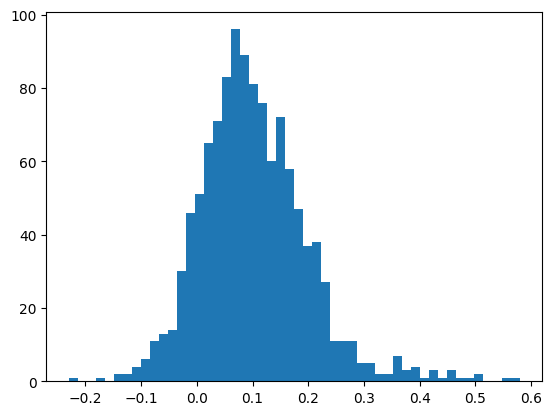

In [10]:
rf_flat = rf_t.values.flatten()
plt.hist(rf_flat, bins=50)
plt.show()

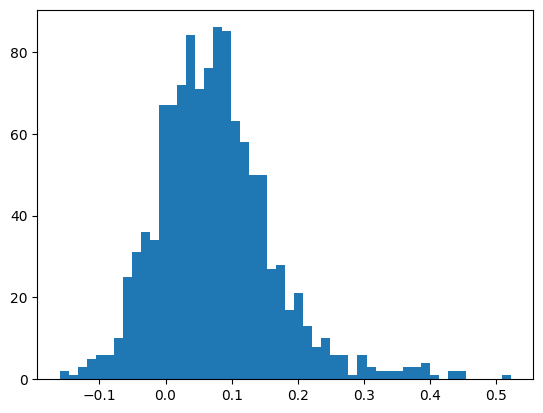

In [11]:
xgb_flat = xgb_t.values.flatten()
plt.hist(xgb_flat, bins=50)
plt.show()

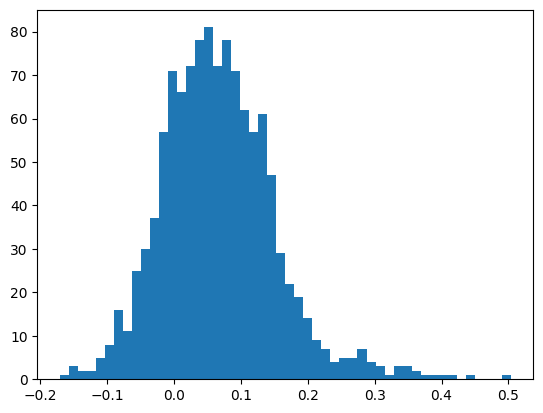

In [12]:
nn_flat = nn_t.values.flatten()
plt.hist(nn_flat, bins=50)
plt.show()

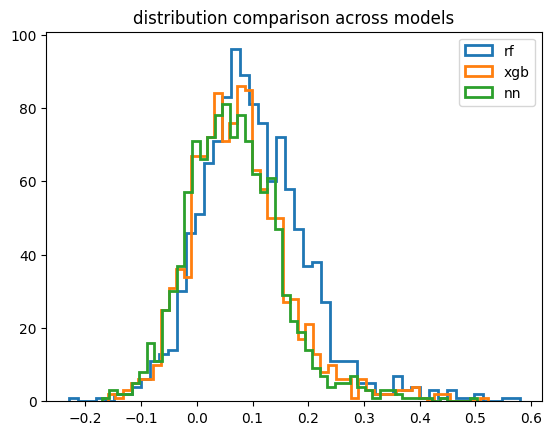

In [13]:
plt.hist(rf_flat, bins=50, histtype="step", linewidth=2, label="rf")
plt.hist(xgb_flat, bins=50, histtype="step", linewidth=2, label="xgb")
plt.hist(nn_flat, bins=50, histtype="step", linewidth=2, label="nn")

plt.title("distribution comparison across models")
plt.legend()
plt.show()

In [14]:
from scipy.stats import kendalltau

In [15]:
tau_rx, _ = kendalltau(rf_t.values.flatten(), xgb_t.values.flatten())
tau_rx

np.float64(0.5945445557902306)

In [16]:
tau_rn, _ = kendalltau(rf_t.values.flatten(), nn_t.values.flatten())
tau_rn

np.float64(0.35141928429125663)

In [17]:
tau_xn, _ = kendalltau(xgb_t.values.flatten(), nn_t.values.flatten())
tau_xn

np.float64(0.33066103446726286)

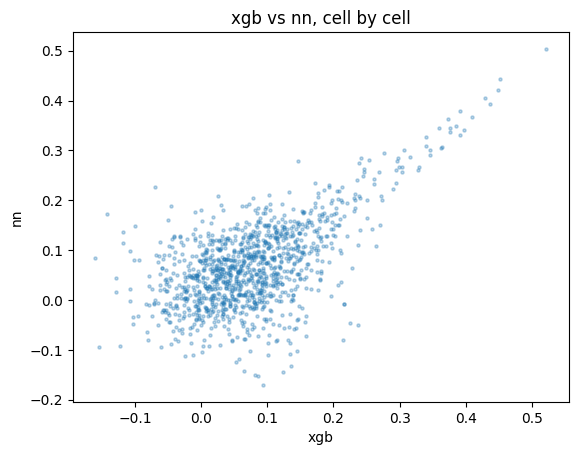

In [18]:
plt.scatter(xgb_t.values.flatten(), nn_t.values.flatten(), alpha=0.3, s=5)
plt.xlabel("xgb")
plt.ylabel("nn")
plt.title("xgb vs nn, cell by cell")
plt.show()

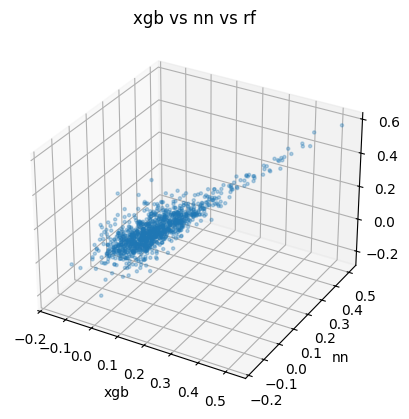

In [19]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(xgb_t.values.flatten(), nn_t.values.flatten(), rf_t.values.flatten(), alpha=0.3, s=5)

ax.set_xlabel("xgb")
ax.set_ylabel("nn")
ax.set_zlabel("rf")
ax.set_title("xgb vs nn vs rf")
plt.show()

In [20]:
diag_rf = np.diag(rf_t.values)
diag_xgb = np.diag(xgb_t.values)
diag_nn = np.diag(nn_t.values)

In [21]:
pairs = [("rf", "xgb", diag_rf, diag_xgb), ("rf", "nn", diag_rf, diag_nn), ("xgb", "nn", diag_xgb, diag_nn)]

for name_a, name_b, a, b in pairs:
    r_p, _ = pearsonr(a, b)
    r_s, _ = spearmanr(a, b)
    r_k, _ = kendalltau(a, b)
    print(f"{name_a} vs {name_b}: pearson={r_p:.3f}, spearman={r_s:.3f}, kendall={r_k:.3f}")

rf vs xgb: pearson=0.965, spearman=0.969, kendall=0.854
rf vs nn: pearson=0.963, spearman=0.942, kendall=0.793
xgb vs nn: pearson=0.951, spearman=0.947, kendall=0.818


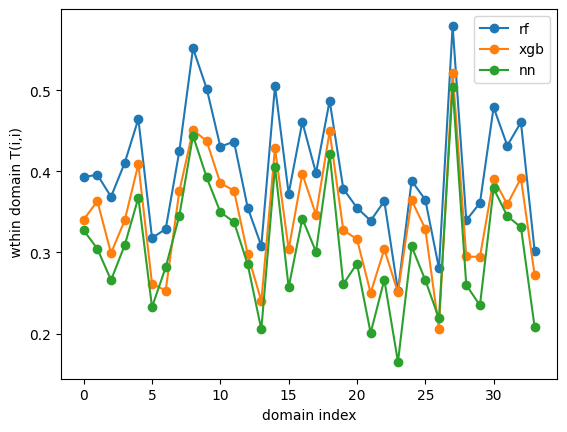

In [23]:
x = np.arange(len(diag_rf))
plt.plot(x, diag_rf, label="rf", marker="o")
plt.plot(x, diag_xgb, label="xgb", marker="o")
plt.plot(x, diag_nn, label="nn", marker="o")
plt.xlabel("domain index")
plt.ylabel(" wthin domain T(i,i)")
plt.legend()
plt.show()

In [24]:
def off_diagonal(df):
    # pull everything except the diagonal, return as flat array
    arr = df.values.copy().astype(float)
    np.fill_diagonal(arr, np.nan)
    return arr.flatten()

rf_off = off_diagonal(rf_t)
xgb_off = off_diagonal(xgb_t)
nn_off = off_diagonal(nn_t)

In [25]:
mask = ~np.isnan(rf_off) & ~np.isnan(xgb_off) & ~np.isnan(nn_off)

In [26]:
for name_a, name_b, a, b in [("rf", "xgb", rf_off, xgb_off), ("rf", "nn", rf_off, nn_off), ("xgb", "nn", xgb_off, nn_off)]:
    tau, _ = kendalltau(a[mask], b[mask])
    print(f"{name_a} vs {name_b}, off-diagonal only: kendall tau={tau:.3f}")

rf vs xgb, off-diagonal only: kendall tau=0.570
rf vs nn, off-diagonal only: kendall tau=0.312
xgb vs nn, off-diagonal only: kendall tau=0.290


In [27]:
def row_correlations(mat_a, mat_b):
    n = mat_a.shape[0]
    corrs = []
    for i in range(n):
        row_a = mat_a.values[i, :]
        row_b = mat_b.values[i, :]
        c, _ = kendalltau(row_a, row_b)
        corrs.append(c)
    return np.array(corrs)

row_rx = row_correlations(rf_t, xgb_t)
row_rn = row_correlations(rf_t, nn_t)
row_xn = row_correlations(xgb_t, nn_t)

In [28]:
print("mean row tau, rf vs xgb:", np.nanmean(row_rx))
print("mean row tau, rf vs nn:", np.nanmean(row_rn))
print("mean row tau, xgb vs nn:", np.nanmean(row_xn))

mean row tau, rf vs xgb: 0.6033343818810948
mean row tau, rf vs nn: 0.3436091013945686
mean row tau, xgb vs nn: 0.3223235818391528


In [29]:
worst = np.argsort(row_rn)[:5]
print("domains with lowest rf vs nn row agreement:", worst)

domains with lowest rf vs nn row agreement: [28 33 29 15  1]


In [30]:
within_rf = np.diag(rf_t.values) # get in-domain i=j performane
within_xgb = np.diag(xgb_t.values)
within_nn = np.diag(nn_t.values)

mean_rf = np.mean(within_rf) # average it for a stability score
mean_xgb = np.mean(within_xgb)
mean_nn = np.mean(within_nn)

In [31]:
print(f"rf {mean_rf:.4f}")
print(f"nn {mean_nn:.4f}")
print(f"xgb {mean_xgb:.4f}")

rf 0.3996
nn 0.3061
xgb 0.3419


In [ ]:
# rf has most reliabiloity, fits better across domains, followed by xgb and then nn
# final transfer matrix will be weighted avg of each - 50%rf, 30%xgb, 20%nn

In [ ]:
w_rf = 0.5
w_xgb = 0.3
w_nn = 0.2

In [34]:
weighted_vals = (w_rf * rf_t.values) + (w_xgb * xgb_t.values) + (w_nn * nn_t.values)

In [36]:
final_t = pd.DataFrame(
    weighted_vals, 
    index=rf_t.index, 
    columns=rf_t.columns
)

In [38]:
0.5*0.392+0.3*0.340+0.2*0.327 # should be ~0.364

0.36340000000000006

In [37]:
final_t

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.364017,0.277422,0.095222,0.073841,0.204885,0.079781,0.135405,0.135528,0.176623,0.036658,...,0.202560,0.212488,0.140741,0.278076,0.118713,0.000636,0.093470,0.127338,0.037930,0.034713
1,0.137598,0.367750,0.038401,0.031446,0.184816,0.053259,0.097157,0.105102,0.127127,0.045803,...,0.169091,0.041817,0.043815,0.215354,0.099725,0.043962,0.079698,0.152422,0.030017,-0.013089
2,0.140110,0.170057,0.327185,0.058541,0.147231,0.111992,0.107481,0.152160,0.130447,0.045841,...,0.156748,0.163730,0.096526,0.197245,0.068973,0.050732,-0.004986,0.156512,0.046006,0.009509
4,0.212748,0.224196,0.110825,0.368732,0.178380,0.183707,0.119660,0.191922,0.142812,0.051166,...,0.172141,0.226234,0.145276,0.272192,0.190192,0.008473,0.038469,0.297286,0.120644,0.044108
5,0.128467,0.142704,0.071152,0.061922,0.428339,0.103385,0.120428,0.187005,0.216916,0.084080,...,0.154954,0.140368,0.099823,0.270381,0.131706,-0.012570,0.118491,0.190798,0.063290,0.045752
6,0.156580,0.188187,0.035215,0.209449,0.147501,0.283900,0.105682,0.107699,0.105245,0.015395,...,0.153988,0.185203,0.093712,0.208891,0.168088,-0.028059,0.105688,0.291945,0.098842,0.001008
7,0.125648,0.072091,0.070654,0.085679,0.080134,0.101767,0.296596,0.084215,0.162836,0.057170,...,0.148311,0.181431,0.133886,0.187934,0.204956,0.018709,0.042540,0.112903,-0.000090,0.008276
8,0.133942,0.178126,-0.024242,0.031348,0.075615,0.088311,0.131749,0.394086,0.004771,0.014214,...,0.084989,0.101258,0.046603,0.079202,0.052995,0.016992,0.024468,0.202354,0.035387,0.001897
11,0.203558,0.199154,0.084844,0.086230,0.222565,0.049364,0.106071,0.148079,0.499865,0.012823,...,0.237974,0.108115,0.092370,0.366971,0.175930,-0.005914,0.144240,0.139467,-0.021466,0.048089
12,0.095321,0.147755,-0.010589,0.094102,0.138684,0.072545,0.047314,0.031103,0.121176,0.460649,...,0.128238,-0.051013,0.064498,0.164864,0.064644,0.069445,0.079611,0.078043,0.080652,-0.041666


In [40]:
final_t.to_csv("transfer_matrix.csv")